In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


This notebook contains the calculations that derive the maximum consumption of red and red processed meat that correspond to a population level reduction in all meat.  

In [ ]:
%cd /content/drive/MyDrive/mSHIFT_SHeS/

/content/drive/MyDrive/mSHIFT_SHeS


In [ ]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path
from utils import add_code_path
add_code_path()

data_path = Path("data")

In [ ]:
# Set the plot formatting
plt.rcParams["font.family"] = 'serif'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["axes.formatter.use_mathtext"] = True

In [ ]:
df_baseline = pd.read_parquet('Notebooks/df_baseline.parquet')

In [ ]:
all_meat_food_groups = ['Beefg',
'Lambg',
'Porkg',
'ProcessedRedMeatg',
'OtherRedMeatg',
'Burgersg',
'Sausagesg',
'Offalg',
'Poultryg',
'GameBirdsg',
'ProcessedPoultryg']


df_baseline["all meat intake"] = df_baseline[all_meat_food_groups].sum(axis=1)

# Code for evaluating percentage reductions from a maximum red and red processed meat itake

In [ ]:
def ind_level_reduction(row, threshold):

  if row['Total RRPM baseline'] > threshold:
    reduction = row['Total RRPM baseline'] - threshold
  else:
    reduction = 0

  return reduction

def overall_reduction_for_threshold(df_baseline: pd.DataFrame, RRPM_max: float):

  df_baseline['RRPM reduction'] = df_baseline.apply(lambda row: ind_level_reduction(row, threshold=RRPM_max), axis=1)
  reduction = (df_baseline['RRPM reduction']*df_baseline['Sample Weight']).sum()
  all_meat_consumption = (df_baseline['all meat intake']*df_baseline['Sample Weight']).sum()
  reduction = (reduction/all_meat_consumption)*100

  return reduction

def reductions_data(df_baseline):

  reductions = []
  for i in range(300):
    reduction = overall_reduction_for_threshold(df_baseline=df_baseline, RRPM_max=i)
    reductions.append(reduction)

  return reductions

# Plot the relationship between max red meat and % reduction in all meat

In [ ]:
reductions_data = reductions_data(df_baseline=df_baseline)

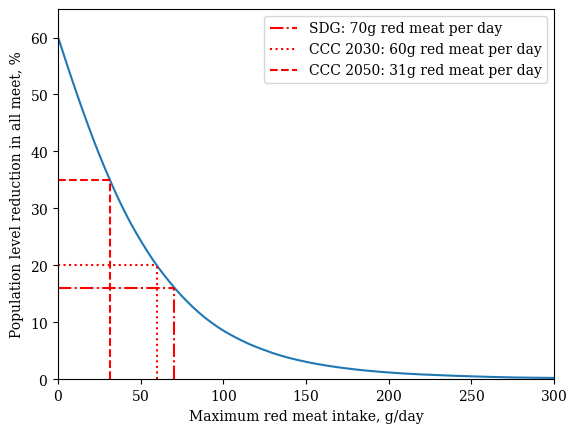

In [ ]:
X = np.linspace(0, 300, 300)
Y = reductions_data

plt.plot(X, Y)
plt.xlabel("Maximum red meat intake, g/day")
plt.ylabel("Population level reduction in all meet, %")

interpolation_function = interp1d(Y, X, bounds_error=False, fill_value="extrapolate")

X_20 = interpolation_function(20)  # Find the x-value where y=20
X_35 = interpolation_function(35)  # Find the x-value where y=35
X_SDG = interpolation_function(16)

# Define the upper bound for the horizontal line
plt.plot([0, X_SDG], [16, 16], color='red', linestyle='-.')  # Line from x=0 to x=X_max
plt.plot([X_SDG, X_SDG], [0, 16], color='red', linestyle='-.', label=f"SDG: 70g red meat per day")  # Line from y=0 to y=35

plt.plot([0, X_20], [20, 20], color='red', linestyle='dotted')  # Line from x=0 to x=X_max
plt.plot([X_20, X_20], [0, 20], color='red', linestyle='dotted', label=f"CCC 2030: 60g red meat per day")  # Line from y=0 to y=20

plt.plot([0, X_35], [35, 35], color='red', linestyle='--')  # Line from x=0 to x=X_max
plt.plot([X_35, X_35], [0, 35], color='red', linestyle='--', label=f"CCC 2050: 31g red meat per day")  # Line from y=0 to y=35

plt.xlim(0,300)
plt.ylim(0,65)
plt.legend()
#plt.savefig("Plots/Paper figures/High consumer thresholds/high_consumers.png", dpi=300)
plt.show()